#**01) Entendimento do Negócio**

##**Definição do problema**

<div align="justify" style="font-size:16px;">
O conjunto de dados utilizado neste projeto refere-se a uma campanha de marketing realizada por uma instituição bancária, com o objetivo de promover a assinatura de produtos financeiros a prazo. A análise proposta contempla a aplicação de técnicas de pré-processamento e modelos de Aprendizado de Máquina, visando avaliar e comparar o desempenho dos algoritmos na previsão da adesão dos clientes a esses produtos.
</div>

##**Entrada: Dataset(s)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
dataset = pd.read_csv('data/bank.csv')
dataset.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [68]:
dataset

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [69]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [70]:
dataset.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [71]:
dataset.duplicated().sum()

np.int64(0)

##**Saída: Dicionário de Dados**

* **idade:** (numérico)

* **profissão:** tipo de trabalho (categórico: "administração", "desconhecido", "desempregado", "gerência", "empregada doméstica", "empreendedor", "estudante", "operário", "autônomo", "aposentado", "técnico", "serviços")

* **estado civil:** (categórico: "casado", "divorciado", "solteiro"; obs: "divorciado" inclui divorciado ou viúvo)

* **escolaridade:** (categórico: "desconhecido", "ensino médio", "ensino fundamental", "ensino superior")

* **inadimplente:** possui crédito em inadimplência? (binário: "sim", "não")

* **saldo:** saldo médio anual em euros (numérico)

* **financiamento imobiliário:** possui empréstimo habitacional? (binário: "sim", "não")

* **empréstimo pessoal:** possui empréstimo pessoal? (binário: "sim", "não")

* **tipo de contato:** meio de comunicação (categórico: "desconhecido", "telefone", "celular")

* **dia:** dia do mês do último contato (numérico)

* **mês:** mês do último contato no ano (categórico: "jan", "feb", "mar", ..., "nov", "dec")

* **duração:** duração do último contato em segundos (numérico)

* **campanha:** número de contatos realizados durante esta campanha com o cliente (numérico, inclui o último contato)

* **dias_desde_último_contato:** número de dias desde o último contato do cliente em uma campanha anterior (numérico; -1 significa que o cliente não foi contatado anteriormente)

* **contatos_anteriores:** número de contatos realizados antes desta campanha com o cliente (numérico)

* **resultado_campanha_anterior:** resultado da campanha anterior (categórico: "desconhecido", "outro", "fracasso", "sucesso")

* **depósito:** o cliente assinou um depósito a prazo? (binário: "sim", "não")

#**02) Pré-Processamento**

##**Obtenção e Preparação dos Dados**

In [72]:
dataset.columns = dataset.columns.str.upper()
dataset

,AGE,JOB,MARITAL,EDUCATION,DEFAULT,BALANCE,HOUSING,LOAN,CONTACT,DAY,MONTH,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,DEPOSIT
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [73]:
dataset.columns = ['IDADE', 'PROFISSÃO', 'ESTADO_CIVIL', 'ESCOLARIDADE', 'INADIMPLENTE', 'SALDO', 'FINANC_IMOBILIÁRIO', 'EMPRÉST_PESSOAL', 'TIPO_CONTATO', 'DIA', 'MÊS',
'DURAÇÃO', 'CAMPANHA', 'DIAS_ÚLT_CONTATO', 'CONTATOS_ANT', 'RESULTADO_ANT', 'ASSINOU_DEPÓSITO']

dataset.head()

,IDADE,PROFISSÃO,ESTADO_CIVIL,ESCOLARIDADE,INADIMPLENTE,SALDO,FINANC_IMOBILIÁRIO,EMPRÉST_PESSOAL,TIPO_CONTATO,DIA,MÊS,DURAÇÃO,CAMPANHA,DIAS_ÚLT_CONTATO,CONTATOS_ANT,RESULTADO_ANT,ASSINOU_DEPÓSITO
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [74]:
dataset.describe()

,IDADE,SALDO,DIA,DURAÇÃO,CAMPANHA,DIAS_ÚLT_CONTATO,CONTATOS_ANT
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


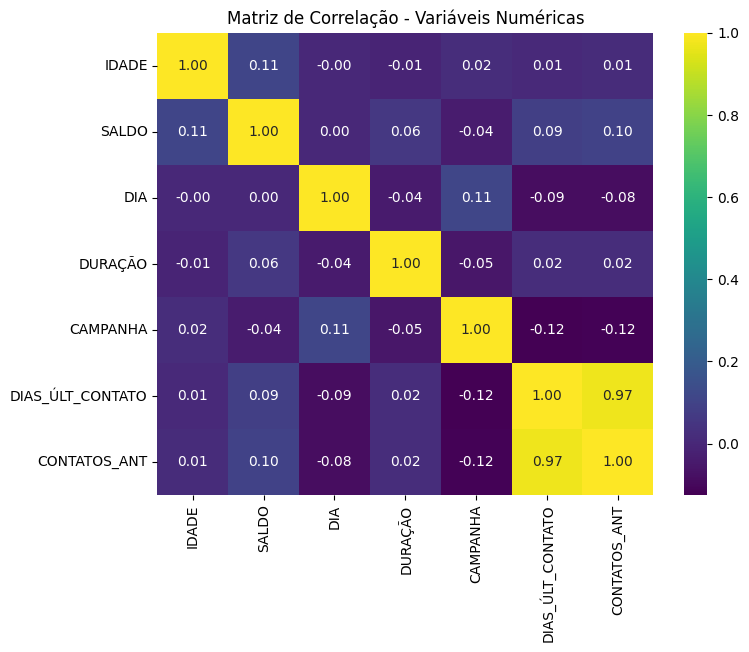

In [75]:
df_numeric = ['IDADE', 'SALDO', 'DIA', 'DURAÇÃO', 'CAMPANHA', 'DIAS_ÚLT_CONTATO', 'CONTATOS_ANT']
corr_mat = dataset[df_numeric].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, cmap='viridis', fmt=".2f")
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.show()

In [76]:
corr_mat

,IDADE,SALDO,DIA,DURAÇÃO,CAMPANHA,DIAS_ÚLT_CONTATO,CONTATOS_ANT
IDADE,1.000000,0.105988,-0.000512,-0.013588,0.018793,0.006258,0.012221
SALDO,0.105988,1.000000,0.000275,0.057609,-0.038962,0.086095,0.097157
DIA,-0.000512,0.000275,1.000000,-0.044205,0.110350,-0.086707,-0.084806
DURAÇÃO,-0.013588,0.057609,-0.044205,1.000000,-0.053894,0.018096,0.017544
CAMPANHA,0.018793,-0.038962,0.110350,-0.053894,1.000000,-0.124045,-0.118324
DIAS_ÚLT_CONTATO,0.006258,0.086095,-0.086707,0.018096,-0.124045,1.000000,0.969272
CONTATOS_ANT,0.012221,0.097157,-0.084806,0.017544,-0.118324,0.969272,1.000000


Evitamos utilizar variáveis altamente correlacionadas (multicolinearidade) porque elas trazem informações repetidas,
dificultando a interpretação dos coeficientes, causando instabilidade no modelo e podendo levar ao overfitting.
Por isso, é recomendado manter apenas uma entre variáveis com correlação muito alta (ex: acima de 0.9).

In [77]:
from sklearn.feature_selection import SelectKBest, f_classif

x = dataset[['IDADE', 'SALDO', 'DIA', 'DURAÇÃO', 'CAMPANHA', 'DIAS_ÚLT_CONTATO', 'CONTATOS_ANT']]
y = dataset['ASSINOU_DEPÓSITO']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(x, y)

print("Scores das variáveis numéricas:")
for name, score in zip(x.columns, selector.scores_):
    print(f"{name}: {score:.2f}")

Scores das variáveis numéricas:
IDADE: 13.61
SALDO: 73.94
DIA: 35.52
DURAÇÃO: 2864.17
CAMPANHA: 186.13
DIAS_ÚLT_CONTATO: 262.49
CONTATOS_ANT: 222.68


In [78]:
dataset

,IDADE,PROFISSÃO,ESTADO_CIVIL,ESCOLARIDADE,INADIMPLENTE,SALDO,FINANC_IMOBILIÁRIO,EMPRÉST_PESSOAL,TIPO_CONTATO,DIA,MÊS,DURAÇÃO,CAMPANHA,DIAS_ÚLT_CONTATO,CONTATOS_ANT,RESULTADO_ANT,ASSINOU_DEPÓSITO
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


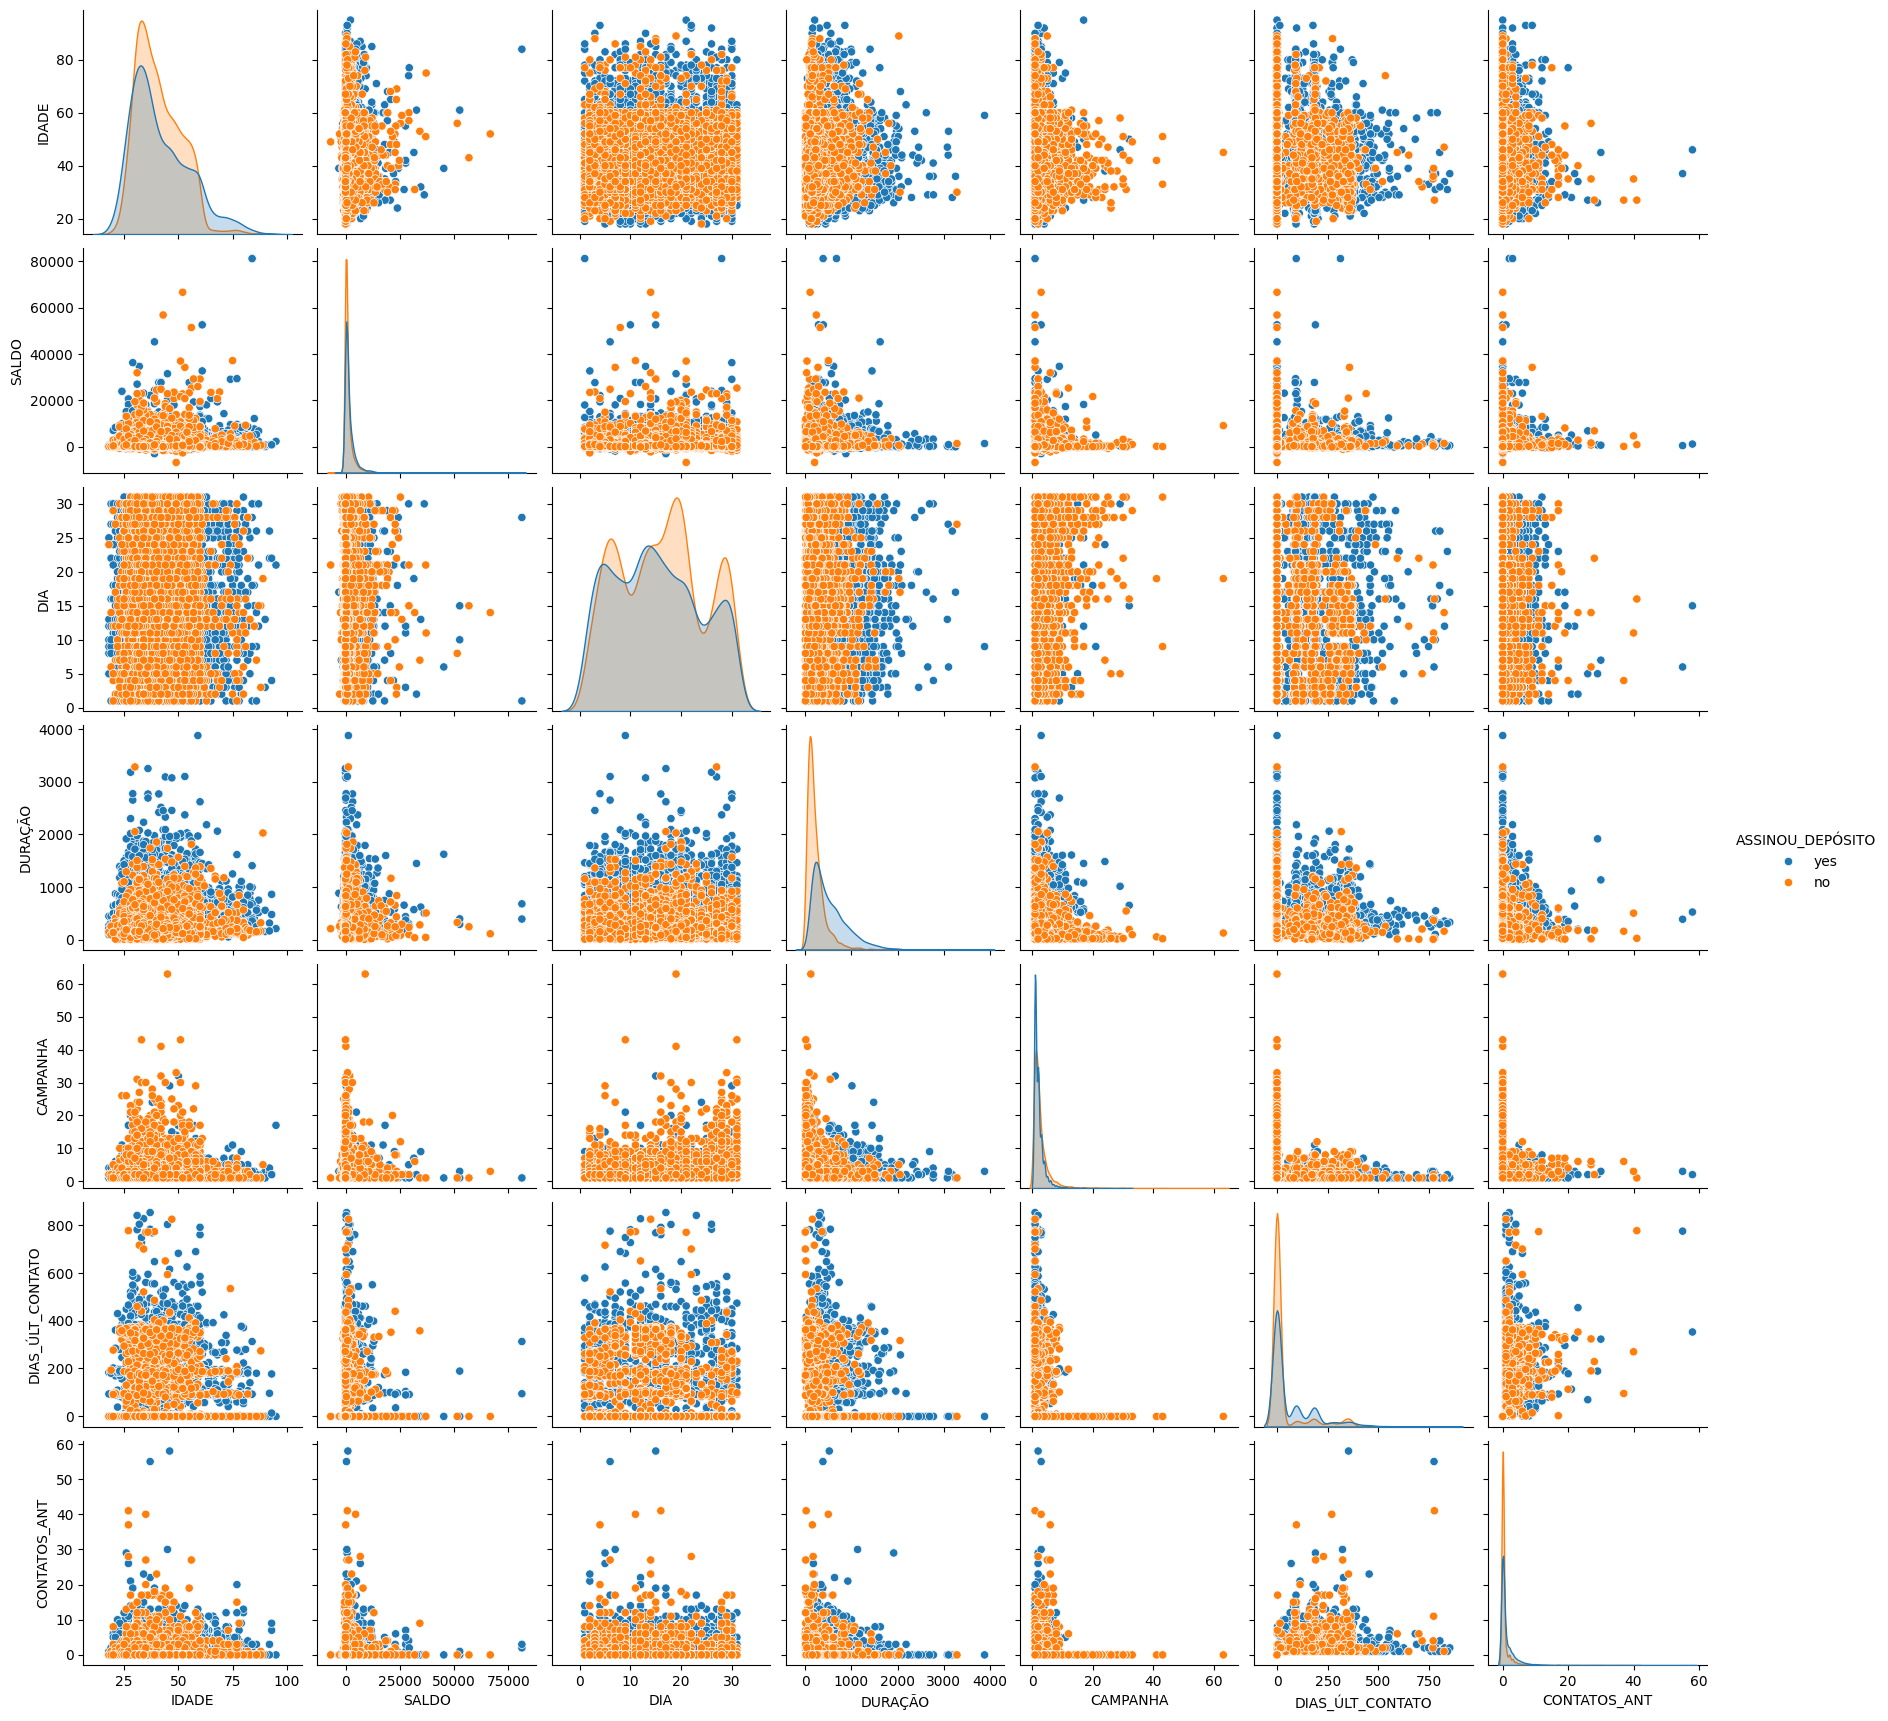

In [79]:
sns.pairplot(dataset, hue='ASSINOU_DEPÓSITO')

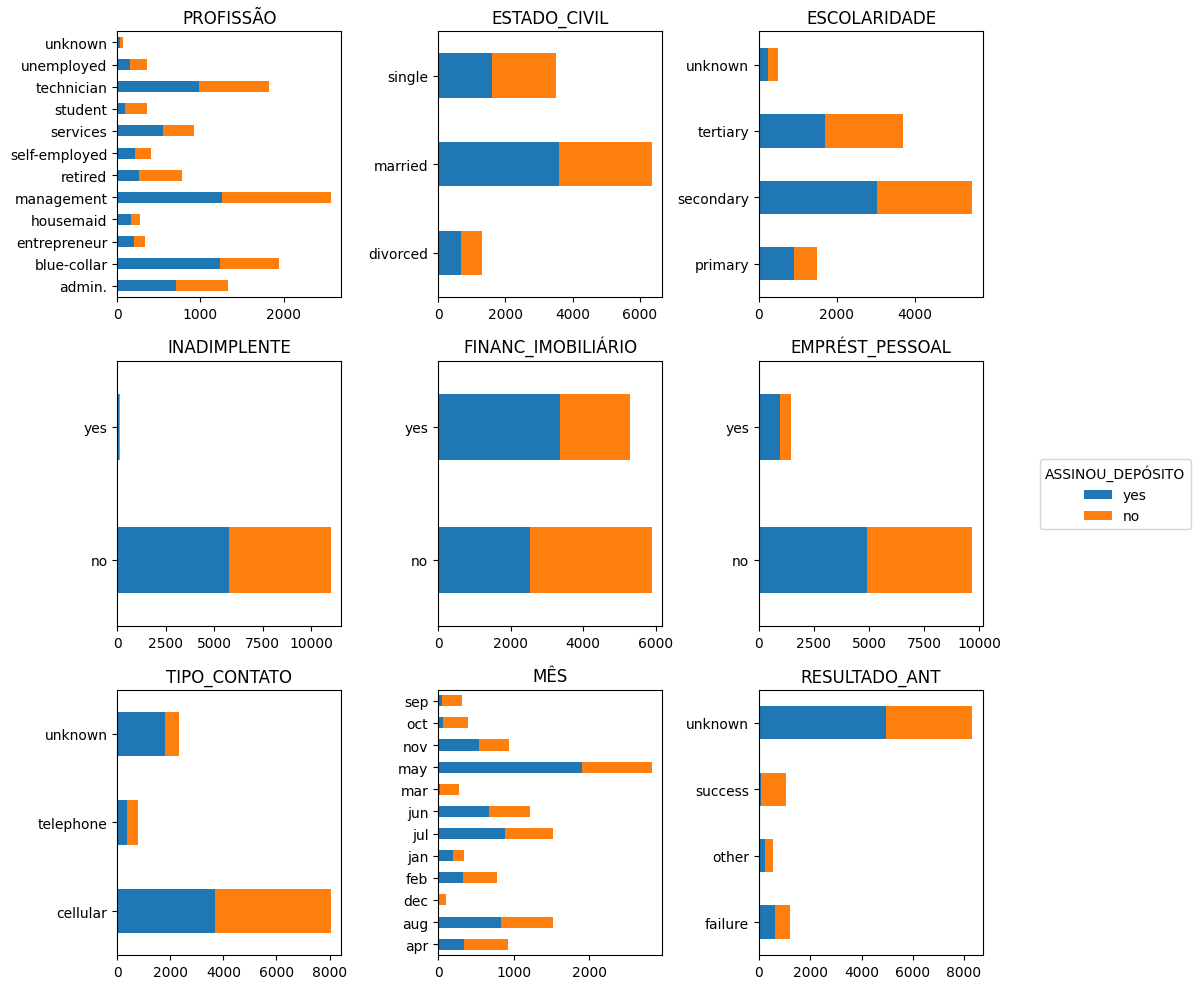

In [80]:
df_features = ['PROFISSÃO', 'ESTADO_CIVIL', 'ESCOLARIDADE', 'INADIMPLENTE', 'FINANC_IMOBILIÁRIO', 'EMPRÉST_PESSOAL', 'TIPO_CONTATO', 'MÊS', 'RESULTADO_ANT']

ncols = 3
nrows = (len(df_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 10))
axes = axes.flatten()

cores = ['#1f77b4', '#ff7f0e']
labels = dataset['ASSINOU_DEPÓSITO'].unique()

for ax, col in zip(axes, df_features):
    pd.crosstab(dataset[col], dataset['ASSINOU_DEPÓSITO']).plot(kind='barh', stacked=True, legend=False, ax=ax)
    ax.set_title(col); ax.set_ylabel('')

for ax in axes[len(df_features):]: fig.delaxes(ax)
fig.legend(labels, title='ASSINOU_DEPÓSITO', loc='center right')
plt.tight_layout(rect=[0, 0, 0.85, 1]); plt.show()


In [81]:
df_features = ['PROFISSÃO', 'ESTADO_CIVIL', 'ESCOLARIDADE', 'INADIMPLENTE', 'FINANC_IMOBILIÁRIO', 'EMPRÉST_PESSOAL', 'TIPO_CONTATO', 'MÊS', 'RESULTADO_ANT']

df_cat = dataset[df_features].copy()

df_cat = df_cat.astype(str)

# Codifica as variáveis com LabelEncoder
le = LabelEncoder()
for col in df_cat.columns:
    df_cat[col] = le.fit_transform(df_cat[col])

y = dataset['ASSINOU_DEPÓSITO']


In [82]:
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(df_cat, y)

# Resultados
print("Scores das variáveis categóricas:")
scores = pd.Series(chi2_selector.scores_, index=df_features)
print(scores.sort_values(ascending=False))

Scores das variáveis categóricas:
TIPO_CONTATO          953.667451
FINANC_IMOBILIÁRIO    244.474430
EMPRÉST_PESSOAL       118.635404
PROFISSÃO             103.960727
RESULTADO_ANT          67.848776
ESCOLARIDADE           44.909241
MÊS                    28.774412
INADIMPLENTE           18.193635
ESTADO_CIVIL           16.646005
dtype: float64


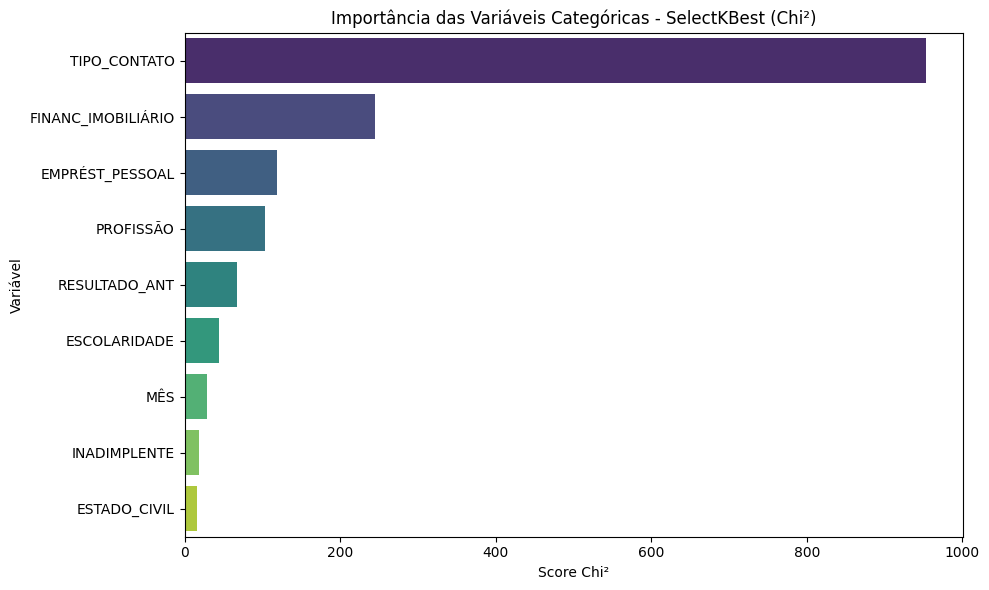

In [83]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=scores.sort_values(ascending=False),
    y=scores.sort_values(ascending=False).index,
    hue=scores.sort_values(ascending=False).index,
    palette='viridis',
    dodge=False
)
plt.title("Importância das Variáveis Categóricas - SelectKBest (Chi²)")
plt.xlabel("Score Chi²")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()


In [84]:
df = dataset.copy()

le = LabelEncoder()
for col in df_features:
    df[col] = le.fit_transform(df[col])

df['ASSINOU_DEPÓSITO'] = le.fit_transform(df['ASSINOU_DEPÓSITO'])

df_model = df.drop(columns=['DURAÇÃO', 'CONTATOS_ANT', 'ASSINOU_DEPÓSITO'])
df_target = df['ASSINOU_DEPÓSITO']

In [85]:
X = df_model
y = df_target

#**03) Desenvolvimento do(s) Modelo(s)**

##**Treinamento**

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
model = LogisticRegression(max_iter=10000)

In [88]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

##**Validação**

In [89]:
scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

print("Acurácias por fold:", scores)
print("Acurácia média:", np.mean(scores))

Acurácias por fold: [0.65005599 0.64837626 0.6556551  0.65397536 0.64201681]
Acurácia média: 0.6500159033378189


##**Teste**

In [90]:
y_pred = model.predict(X_test)

In [91]:
y_pred

array([1, 0, 1, ..., 1, 1, 1])

In [92]:
print('Intercepto:', model.intercept_[0])
print('Coeficientes:', model.coef_[0])

Intercepto: -0.4867063058352978
Coeficientes: [ 5.75596012e-03  9.01102155e-03  1.44631591e-01  1.42037129e-01
 -3.40722007e-01  2.95887577e-05 -6.50384505e-01 -5.36650200e-01
 -5.64845270e-01 -7.18311156e-03  3.33218413e-02 -1.03530604e-01
  3.06209065e-03  1.41818149e-01]


In [93]:
y_test

,ASSINOU_DEPÓSITO
5527,0
4541,1
1964,1
5007,1
8928,0
...,...
376,1
5544,0
10749,0
3881,1


##**Avaliação**

In [94]:
y_pred = model.predict(X_test)
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print("Acurácia:", accuracy_score(y_test, y_pred))

Matriz de Confusão:
[[794 372]
 [364 703]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.69      0.68      0.68      1166
           1       0.65      0.66      0.66      1067

    accuracy                           0.67      2233
   macro avg       0.67      0.67      0.67      2233
weighted avg       0.67      0.67      0.67      2233

Acurácia: 0.6703985669502911


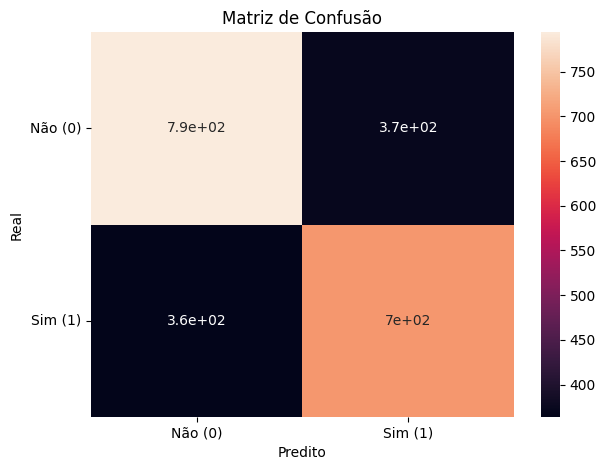

In [95]:
matriz = confusion_matrix(y_test, y_pred)

sns.heatmap(matriz, annot=True)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.xticks([0.5, 1.5], ['Não (0)', 'Sim (1)'])
plt.yticks([0.5, 1.5], ['Não (0)', 'Sim (1)'], rotation=0)

plt.tight_layout()
plt.show()


##**Comparação**
##Random Forest Classifier

In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [97]:
X = df_model.copy()
y = df_target.copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'max_depth': [10, 15],     # profundidade máxima das árvores
    'min_samples_split': [2, 15], # número mínimo de amostras por divisão
    'min_samples_leaf': [1, 2],   # número mínimo de amostras por folha
    'criterion': ['gini', 'entropy'] # critério de métrica usada para medir a pureza dos nós
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Melhores parâmetros encontrados:", grid_search.best_params_)

print("\nMelhor score na validação cruzada:", grid_search.best_score_)

y_pred = grid_search.best_estimator_.predict(X_test)
print("\nAcurácia no conjunto de teste:")
print(accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Melhores parâmetros encontrados: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 15}

Melhor score na validação cruzada: 0.7250521798865124

Acurácia no conjunto de teste:
0.7308553515450067


In [98]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=15,
    min_samples_leaf=1,
    criterion='gini',
    random_state=42
)

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Acurácias por fold:", scores)
print("Acurácia média:", np.mean(scores))

Acurácias por fold: [0.46618898 0.62068966 0.73611111 0.75179211 0.63530466]
Acurácia média: 0.6420173047814872


In [99]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_split=15, random_state=42)

In [100]:
y_pred = model_rf.predict(X_test)
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print("Acurácia:", accuracy_score(y_test, y_pred))

Matriz de Confusão:
[[979 187]
 [414 653]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.70      0.84      0.77      1166
           1       0.78      0.61      0.68      1067

    accuracy                           0.73      2233
   macro avg       0.74      0.73      0.72      2233
weighted avg       0.74      0.73      0.73      2233

Acurácia: 0.7308553515450067


#**04) Conclusão**

<div align="justify" style="font-size:16px;">

O método adotado neste projeto segue um pipeline de aprendizado supervisionado composto por quatro etapas: (1) entendimento do negócio, (2) pré-processamento dos dados, (3) desenvolvimento e avaliação dos modelos e (4) conclusão. O objetivo é prever a probabilidade de clientes aderirem a produtos financeiros a prazo, com base em dados provenientes de uma campanha de marketing bancário.

Inicialmente, realizou-se a análise exploratória dos dados, incluindo a identificação de linhas nulas e duplicadas. Em seguida, na etapa de pré-processamento, analisaram-se as variáveis numéricas e categóricas. Para as numéricas, aplicaram-se estatísticas descritivas e matriz de correlação. Para as categóricas, utilizaram-se de análises gráficas para avaliar a distribuição e associação com a variável-alvo. Concluída essa análise, os dados foram divididos entre variáveis preditoras (X) e variável-alvo (y).

Na etapa de modelagem, desenvolveu-se inicialmente um modelo de Regressão Logística. Para reduzir vieses, os dados foram divididos em treino e teste, com aplicação de validação cruzada. O desempenho foi avaliado por métricas de classificação: Acurácia, que indica a proporção de previsões corretas; Precisão, que mede a proporção de positivos previstos corretamente; Recall, que avalia a capacidade do modelo de identificar todos os casos positivos; e F1-Score, que equilibra Precisão e Recall. Esse modelo apresentou acurácia aproximada de 67%, com tendência a identificar melhor clientes que não adeririam aos produtos.

Buscando maior desempenho, implementou-se o modelo Random Forest Classifier, um algoritmo baseado em múltiplas árvores de decisão. Para otimização, aplicou-se o método Grid Search com validação cruzada, ajustando hiperparâmetros como profundidade máxima das árvores (max_depth), número mínimo de amostras para divisão (min_samples_split) e para folhas (min_samples_leaf). O modelo final apresentou acurácia aproximada de 74%, superando o desempenho da regressão logística e demonstrando boa capacidade de generalização em média.

Comparativamente, o Random Forest mostrou-se mais adequado para o problema, devido à sua capacidade de lidar com interações complexas entre variáveis e reduzir o risco de overfitting por meio da combinação de múltiplas árvores. A escolha desse modelo reflete a busca por soluções com maior poder preditivo, mantendo um nível básico de interpretabilidade por meio da análise da importância das variáveis.

Conclui-se que a aplicação de modelo de aprendizado supervisionado possibilitou identificar clientes com maior probabilidade de adesão a produtos financeiros a prazo. A solução proposta tem potencial para auxiliar a instituição financeira na formulação de estratégias de marketing mais assertivas, direcionando recursos para perfis com maior chance de conversão, o que pode resultar em campanhas mais eficientes e rentáveis.

</div>